# Improved Node-Edge Traversal Reconstruction

This notebook reconstructs a clean node-to-edge traversal sequence from raw tracking data, using graph structure to:
- Fill in missing nodes/edges based on connectivity
- Filter tracking noise and artifacts  
- Validate transitions follow graph logic
- Compute accurate durations at each location

## Requirements

- `summary_df.pkl` - Frame-by-frame tracking with `headstage_graph_node` and `headstage_graph_edge` columns
- Graph structure file (e.g., `FullMazeGrid.pkl`) with node positions and edge definitions

## Usage

1. Set the date variables (DD, MM, YYYY) to load your summary_df
2. Run all cells to reconstruct the improved traversal
3. Output is saved to `improved_traversal_df.pkl` and `.csv`

## Key Parameters

- `noise_threshold_frames=5` - Maximum frames for a location to be considered noise

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pickle
import datetime
from pathlib import Path
import scipy.io

In [178]:
DD, MM, YYYY = "21", "08", "2025"
summary_pkl_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{DD}_{MM}_{YYYY}/summary_df.pkl"

summary_df = pd.read_pickle(summary_pkl_path)
summary_df.head()

headstage                              ear_L                         \
            x           y likelihood           x           y likelihood   
0   10.106240  935.484558   0.497514    7.243033   78.381943   0.333607   
1  148.717056  802.893433   0.122756  155.277069  792.898315   0.156270   
2  148.730759  802.908447   0.112014  155.321304  792.572693   0.135378   
3  148.534470  802.695007   0.107952  155.050064  792.590088   0.142095   
4  148.415649  802.933228   0.100557  155.121216  792.566467   0.135168   

        ear_R                            midbody  ... frame_time_in_trial  \
            x           y likelihood           x  ...                       
0    5.269594  940.030762   0.157765    4.632358  ...               0.000   
1  149.473129  790.936707   0.204972  158.882599  ...               0.025   
2  147.600632  795.962646   0.193536  159.002945  ...               0.050   
3  149.435928  790.780945   0.189521  158.509354  ...               0.075   
4  149.743042  790.663147   0.186698  158.877014  ...               0.100   

  trial_length is_exact_multiple has_extra_frame headstage_graph_node  \
                                                                        
0      10.8899             False            True                 None   
1      10.8899             False            True                 None   
2      10.8899             False            True                 None   
3      10.8899             False            True                 None   
4      10.8899             False            True                 None   

  headstage_graph_edge fixed_node reward_node reward_size   lick  
                                                                  
0                 None       None       False         NaN  False  
1                 None       None       False         NaN  False  
2                 None       None       False         NaN  False  
3                 None       None       False         NaN  False  
4                 None       None       False         NaN  False  

[5 rows x 31 columns]

In [179]:
import networkx as nx
# Load the mapping file to get node positions
mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
with open(mapping_file, 'rb') as f:
    mapping_data = pickle.load(f)

# Extract node and edge definitions
nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

print(f"Found {len(nodes_dict)} nodes in mapping")
print(f"Found {len(edges_dict)} edge definitions")

# Convert node polygons to center positions
node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    
    if polygon and len(polygon) >= 2:
        # Calculate center of bounding box
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        center_x = sum(xs) / len(xs)
        center_y = sum(ys) / len(ys)
        node_positions[node_id] = (center_x, center_y)

print(f"Converted {len(node_positions)} node positions")

# Build graph structure from edges_dict
G = nx.DiGraph()

# Add all nodes
G.add_nodes_from(node_positions.keys())

# Add edges from edges_dict (bidirectional)
edges_added = 0
for edge_key, polygon_list in edges_dict.items():
    nodes = edge_key.split('_')
    if len(nodes) == 2:
        from_node, to_node = nodes
        if from_node in node_positions and to_node in node_positions:
            G.add_edge(from_node, to_node)
            G.add_edge(to_node, from_node)
            edges_added += 2

print(f"\nGraph loaded: {len(G.nodes)} nodes, {edges_added} edges (bidirectional)")
print(f"Graph ready for visualizations!")

Found 126 nodes in mapping
Found 125 edge definitions
Converted 126 node positions

Graph loaded: 126 nodes, 250 edges (bidirectional)
Graph ready for visualizations!


In [180]:
G.nodes

NodeView(('L34', 'L530', 'L52', 'L21', 'L30', 'R531', 'L56', 'R518', 'L517', 'R37', 'L510', 'R36', 'R530', 'L412', 'R525', 'R527', 'R57', 'L43', 'L41', 'L522', 'R45', 'R42', 'R512', 'L42', 'R46', 'R411', 'R32', 'R413', 'L525', 'R54', 'L527', 'R516', 'L529', 'R415', 'R517', 'R0', 'R23', 'R11', 'L58', 'R56', 'R514', 'R510', 'L48', 'L40', 'R48', 'L528', 'L526', 'R55', 'L513', 'L47', 'R43', 'R58', 'R21', 'R22', 'R50', 'L37', 'L36', 'R49', 'L515', 'L45', 'L51', 'L414', 'R414', 'L410', 'L23', 'L10', 'L514', 'R523', 'R526', 'L31', 'R33', 'L50', 'R519', 'L518', 'L22', 'L54', 'R515', 'R520', 'L0', 'L512', 'L49', 'L55', 'R10', 'R44', 'L516', 'R53', 'L531', 'R34', 'R511', 'R522', 'L519', 'L411', 'L523', 'L32', 'L53', 'L33', 'R524', 'R529', 'R528', 'L20', 'R20', 'R59', 'L511', 'L35', 'R40', 'R31', 'R410', 'L520', 'R51', 'R513', 'R412', 'L59', 'L11', 'L57', 'R47', 'L413', 'R521', 'R35', 'L524', 'L46', 'L44', 'L521', 'R41', 'L415', 'R52', 'R30'))

In [181]:
G.edges

OutEdgeView([('L34', 'L48'), ('L34', 'L22'), ('L34', 'L49'), ('L530', 'L415'), ('L52', 'L41'), ('L21', 'L10'), ('L21', 'L33'), ('L21', 'L32'), ('L30', 'L40'), ('L30', 'L20'), ('L30', 'L41'), ('R531', 'R415'), ('L56', 'L43'), ('R518', 'R49'), ('L517', 'L48'), ('R37', 'R23'), ('R37', 'R414'), ('R37', 'R415'), ('L510', 'L45'), ('R36', 'R412'), ('R36', 'R413'), ('R36', 'R23'), ('R530', 'R415'), ('L412', 'L36'), ('L412', 'L524'), ('L412', 'L525'), ('R525', 'R412'), ('R527', 'R413'), ('R57', 'R43'), ('L43', 'L57'), ('L43', 'L31'), ('L43', 'L56'), ('L41', 'L52'), ('L41', 'L30'), ('L41', 'L53'), ('L522', 'L411'), ('R45', 'R510'), ('R45', 'R511'), ('R45', 'R32'), ('R42', 'R55'), ('R42', 'R54'), ('R42', 'R31'), ('R512', 'R46'), ('L42', 'L31'), ('L42', 'L54'), ('L42', 'L55'), ('R46', 'R33'), ('R46', 'R513'), ('R46', 'R512'), ('R411', 'R522'), ('R411', 'R523'), ('R411', 'R35'), ('R32', 'R21'), ('R32', 'R44'), ('R32', 'R45'), ('R413', 'R526'), ('R413', 'R527'), ('R413', 'R36'), ('L525', 'L412'), ('

In [182]:
# Check summary_df structure
print("Summary DataFrame shape:", summary_df.shape)
print("\nColumns:", summary_df.columns.tolist())
print("\nFirst few rows of relevant columns:")
cols_to_check = ['headstage_graph_node', 'headstage_graph_edge', 'frame_time_in_trial']
if all(col in summary_df.columns for col in cols_to_check):
    print(summary_df[cols_to_check].head(20))

Summary DataFrame shape: (138671, 31)

Columns: [('headstage', 'x'), ('headstage', 'y'), ('headstage', 'likelihood'), ('ear_L', 'x'), ('ear_L', 'y'), ('ear_L', 'likelihood'), ('ear_R', 'x'), ('ear_R', 'y'), ('ear_R', 'likelihood'), ('midbody', 'x'), ('midbody', 'y'), ('midbody', 'likelihood'), ('tailbase', 'x'), ('tailbase', 'y'), ('tailbase', 'likelihood'), ('weighted', 'x'), ('weighted', 'y'), ('weighted', 'likelihood'), ('trial_idx', ''), ('frame_idx_global', ''), ('frame_idx_in_trial', ''), ('frame_time_in_trial', ''), ('trial_length', ''), ('is_exact_multiple', ''), ('has_extra_frame', ''), ('headstage_graph_node', ''), ('headstage_graph_edge', ''), ('fixed_node', ''), ('reward_node', ''), ('reward_size', ''), ('lick', '')]

First few rows of relevant columns:
   headstage_graph_node headstage_graph_edge frame_time_in_trial
                                                                
0                  None                 None               0.000
1                  None      

In [183]:
# Check where we have actual tracking data
node_col = ('headstage_graph_node', '')
edge_col = ('headstage_graph_edge', '')

print("Node tracking stats:")
print(f"  Total frames: {len(summary_df)}")
print(f"  Frames with node: {summary_df[node_col].notna().sum()}")
print(f"  Frames with edge: {summary_df[edge_col].notna().sum()}")
print(f"  Frames with both: {(summary_df[node_col].notna() & summary_df[edge_col].notna()).sum()}")
print(f"  Frames with neither: {(summary_df[node_col].isna() & summary_df[edge_col].isna()).sum()}")

# Show some rows with data
print("\nSample rows with node data:")
print(summary_df[summary_df[node_col].notna()].head(10)[[node_col, edge_col, ('frame_time_in_trial', '')]])

Node tracking stats:
  Total frames: 138671
  Frames with node: 94507
  Frames with edge: 41556
  Frames with both: 0
  Frames with neither: 2608

Sample rows with node data:
   headstage_graph_node headstage_graph_edge frame_time_in_trial
                                                                
47                  L56                 None               1.175
48                  L56                 None               1.200
49                  L56                 None               1.225
50                  L56                 None               1.250
51                  L56                 None               1.275
52                  L43                 None               1.300
53                  L43                 None               1.325
54                  L43                 None               1.350
55                  L43                 None               1.375
56                  L43                 None               1.400


## Improved Node-Edge Traversal Reconstruction

This section implements a graph-aware algorithm to reconstruct the complete node-edge-node traversal sequence from tracking data with the following features:
- **Graph logic validation**: Ensures node-edge-node sequences follow graph connectivity
- **Missing data inference**: Fills in missing nodes/edges based on graph structure
- **Noise filtering**: Detects and corrects tracking jumps to distant locations
- **Duration calculation**: Computes time spent at each location
- **Edge-to-edge correction**: Infers missing nodes when edges are directly adjacent

In [184]:
def get_edge_nodes(edge_name):
    """Extract the two nodes from an edge name (e.g., 'L56_L43' or '(L56, L43)' -> ('L56', 'L43'))"""
    if edge_name is None:
        return None, None
    
    edge_str = str(edge_name)
    
    # Handle tuple format: (L56, L43) or ('L56', 'L43')
    if edge_str.startswith('(') and edge_str.endswith(')'):
        edge_str = edge_str[1:-1]  # Remove parentheses
        parts = [p.strip().strip("'\"") for p in edge_str.split(',')]  # Strip quotes too
        if len(parts) == 2:
            return parts[0], parts[1]
    
    # Handle underscore format: L56_L43
    elif '_' in edge_str:
        parts = edge_str.split('_')
        if len(parts) == 2:
            return parts[0], parts[1]
    
    return None, None


def is_valid_non_edge_transition(loc1, loc2):
    """
    Check if a node-to-node transition without an edge is valid.
    Specifically, L/R4X to L/R5X transitions are valid even without edges.
    """
    if loc1 is None or loc2 is None:
        return False
    
    loc1_str = str(loc1).strip("'\"")
    loc2_str = str(loc2).strip("'\"")
    
    # Check for L/R4X to L/R5X pattern (and vice versa)
    # Pattern: starts with L or R, followed by 4 or 5, then any character
    if len(loc1_str) >= 2 and len(loc2_str) >= 2:
        side1, level1 = loc1_str[0], loc1_str[1]
        side2, level2 = loc2_str[0], loc2_str[1]
        
        # Same side (L or R), different levels (4 or 5)
        if side1 == side2 and {level1, level2} == {'4', '5'}:
            return True
    
    return False


def are_neighbors(G, loc1, loc2):
    """
    Check if two locations are neighbors in the graph.
    Handles node-node, node-edge, and edge-edge relationships.
    """
    if loc1 is None or loc2 is None:
        return False
    
    # Convert to strings for comparison
    loc1_str = str(loc1)
    loc2_str = str(loc2)
    
    # Determine types
    loc1_is_edge = ',' in loc1_str or ('_' in loc1_str and loc1_str not in G.nodes)
    loc2_is_edge = ',' in loc2_str or ('_' in loc2_str and loc2_str not in G.nodes)
    
    # Both are nodes
    if not loc1_is_edge and not loc2_is_edge:
        # Check for direct edge
        if G.has_edge(loc1, loc2) or G.has_edge(loc2, loc1):
            return True
        # Check for valid non-edge transitions (L/R4X to L/R5X)
        return is_valid_non_edge_transition(loc1, loc2)
    
    # loc1 is node, loc2 is edge
    if not loc1_is_edge and loc2_is_edge:
        n1, n2 = get_edge_nodes(loc2)
        return loc1 == n1 or loc1 == n2
    
    # loc1 is edge, loc2 is node
    if loc1_is_edge and not loc2_is_edge:
        n1, n2 = get_edge_nodes(loc1)
        return loc2 == n1 or loc2 == n2
    
    # Both are edges - they're neighbors if they share a node
    n1_a, n1_b = get_edge_nodes(loc1)
    n2_a, n2_b = get_edge_nodes(loc2)
    
    shared_nodes = {n1_a, n1_b} & {n2_a, n2_b}
    return len(shared_nodes) > 0


def get_location_type(location):
    """Determine if a location is a node or edge"""
    if location is None or pd.isna(location):
        return None
    
    loc_str = str(location)
    
    # Check for tuple/edge format
    if ',' in loc_str or (loc_str.startswith('(') and loc_str.endswith(')')):
        return 'edge'
    
    # Check for underscore format (but not if it's a node name)
    # We need to be careful here - some node names might have underscores
    # So we check if it can be parsed as an edge
    n1, n2 = get_edge_nodes(location)
    if n1 and n2:
        return 'edge'
    
    return 'node'


def get_shared_node(edge1, edge2):
    """Get the node shared between two edges"""
    n1_a, n1_b = get_edge_nodes(edge1)
    n2_a, n2_b = get_edge_nodes(edge2)
    
    shared = {n1_a, n1_b} & {n2_a, n2_b}
    if len(shared) == 1:
        return list(shared)[0]
    return None


def infer_missing_node_between_edges(edge1, edge2):
    """Infer the connecting node between two edges"""
    return get_shared_node(edge1, edge2)


def find_shortest_path_locations(G, start_loc, end_loc):
    """
    Find the sequence of locations (nodes and edges) on the shortest path between two locations.
    Returns list of locations to traverse from start to end.
    """
    if start_loc is None or end_loc is None:
        return []
    
    # Check if they're already neighbors - no inference needed
    if are_neighbors(G, start_loc, end_loc):
        return [start_loc, end_loc]
    
    # Get the actual nodes involved
    start_type = get_location_type(start_loc)
    end_type = get_location_type(end_loc)
    
    # Get starting node
    if start_type == 'node':
        start_node = start_loc
    else:
        # If starting from edge, use the second node of the edge
        n1, n2 = get_edge_nodes(start_loc)
        start_node = n2 if n2 else n1
    
    # Get ending node
    if end_type == 'node':
        end_node = end_loc
    else:
        # If ending at edge, use the first node of the edge
        n1, n2 = get_edge_nodes(end_loc)
        end_node = n1 if n1 else n2
    
    if start_node is None or end_node is None:
        return []
    
    if start_node not in G.nodes or end_node not in G.nodes:
        return []
    
    try:
        # Find shortest path between nodes
        import networkx as nx
        node_path = nx.shortest_path(G, start_node, end_node)
        
        # Convert node path to location path (including edges)
        location_path = []
        for i in range(len(node_path)):
            location_path.append(node_path[i])
            # Add edge to next node if there is one
            if i < len(node_path) - 1:
                edge_name = f"({node_path[i]}, {node_path[i+1]})"
                location_path.append(edge_name)
        
        return location_path
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []


def get_neighbors(G, location):
    """Get all valid neighbor locations for a given location"""
    if location is None:
        return []
    
    neighbors = []
    
    if location in G.nodes:
        # Node neighbors: connected nodes and edges
        for neighbor_node in G.neighbors(location):
            neighbors.append(neighbor_node)
            # Also add the edge connecting them
            edge_name = f"{location}_{neighbor_node}"
            neighbors.append(edge_name)
    else:
        # Edge neighbors: the two endpoint nodes
        n1, n2 = get_edge_nodes(location)
        if n1:
            neighbors.append(n1)
        if n2:
            neighbors.append(n2)
    
    return neighbors


def filter_session_boundaries(summary_df, likelihood_threshold=0.5, min_consecutive_frames=20):
    """
    Filter out frames at the start and end of session where tracking likelihood is low.
    Keeps only frames after we have min_consecutive_frames with likelihood > threshold.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        DataFrame with ('headstage', 'likelihood') column
    likelihood_threshold : float
        Minimum likelihood to consider as good tracking (default 0.5)
    min_consecutive_frames : int
        Number of consecutive good frames needed to start session (default 20)
    
    Returns:
    --------
    pd.DataFrame : Filtered dataframe
    int, int : start_frame, end_frame indices that were kept
    """
    likelihood_col = ('headstage', 'likelihood')
    
    if likelihood_col not in summary_df.columns:
        print("Warning: No headstage likelihood column found, skipping session filtering")
        return summary_df, 0, len(summary_df) - 1
    
    good_tracking = summary_df[likelihood_col] > likelihood_threshold
    
    # Find start: first position where we have min_consecutive_frames consecutive good frames
    start_idx = None
    for i in range(len(good_tracking) - min_consecutive_frames + 1):
        if good_tracking.iloc[i:i + min_consecutive_frames].all():
            start_idx = i
            break
    
    if start_idx is None:
        print(f"Warning: Could not find {min_consecutive_frames} consecutive good frames at start")
        start_idx = 0
    
    # Find end: last position where we have min_consecutive_frames consecutive good frames
    end_idx = None
    for i in range(len(good_tracking) - min_consecutive_frames, -1, -1):
        if good_tracking.iloc[i:i + min_consecutive_frames].all():
            end_idx = i + min_consecutive_frames - 1
            break
    
    if end_idx is None:
        print(f"Warning: Could not find {min_consecutive_frames} consecutive good frames at end")
        end_idx = len(summary_df) - 1
    
    filtered_df = summary_df.iloc[start_idx:end_idx + 1].copy()
    
    print(f"Session filtering:")
    print(f"  Original frames: {len(summary_df)}")
    print(f"  Filtered frames: {len(filtered_df)}")
    print(f"  Removed from start: {start_idx}")
    print(f"  Removed from end: {len(summary_df) - end_idx - 1}")
    
    return filtered_df, start_idx, end_idx


def merge_consecutive_duplicates(traversal_df):
    """
    Merge consecutive rows with the same location into a single row.
    Combines durations and frame ranges.
    
    Parameters:
    -----------
    traversal_df : pd.DataFrame
        Traversal dataframe with consecutive duplicate locations
    
    Returns:
    --------
    pd.DataFrame : Merged dataframe without consecutive duplicates
    """
    if len(traversal_df) == 0:
        return traversal_df
    
    merged_rows = []
    current_row = traversal_df.iloc[0].to_dict()
    current_frames = [current_row['start_frame'], current_row['end_frame']]
    
    for i in range(1, len(traversal_df)):
        row = traversal_df.iloc[i]
        
        # Check if same location as current
        if row['location'] == current_row['location']:
            # Merge with current row
            current_frames.extend([row['start_frame'], row['end_frame']])
            current_row['end_frame'] = row['end_frame']
            current_row['duration_frames'] += row['duration_frames']
            current_row['duration_time'] += row['duration_time']
            current_row['end_time'] = row['end_time']
            # Keep is_inferred=True if any merged row was inferred
            if row['is_inferred']:
                current_row['is_inferred'] = True
                if current_row['inference_reason'] is None:
                    current_row['inference_reason'] = row['inference_reason']
        else:
            # Different location, save current and start new
            merged_rows.append(current_row.copy())
            current_row = row.to_dict()
            current_frames = [row['start_frame'], row['end_frame']]
    
    # Don't forget the last row
    merged_rows.append(current_row)
    
    merged_df = pd.DataFrame(merged_rows)
    
    duplicates_removed = len(traversal_df) - len(merged_df)
    if duplicates_removed > 0:
        print(f"Merged {duplicates_removed} consecutive duplicate locations")
    
    return merged_df

In [185]:
def reconstruct_traversal(summary_df, G, noise_threshold_frames=5):
    """
    Reconstruct node-edge traversal from tracking data.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        DataFrame with columns ('headstage_graph_node', '') and ('headstage_graph_edge', '')
    G : networkx.Graph
        Graph structure
    noise_threshold_frames : int
        Number of frames to consider as potential noise
    
    Returns:
    --------
    pd.DataFrame with columns:
        - location: node or edge ID
        - location_type: 'node' or 'edge'
        - start_frame: first frame index
        - end_frame: last frame index  
        - duration_frames: number of frames
        - start_time: start time in trial
        - end_time: end time in trial
        - duration_time: time duration
        - is_inferred: whether location was inferred
        - inference_reason: why it was inferred
    """
    
    node_col = ('headstage_graph_node', '')
    edge_col = ('headstage_graph_edge', '')
    time_col = ('frame_time_in_trial', '')
    
    # Combine node and edge into single location column
    df_work = summary_df[[node_col, edge_col, time_col]].copy()
    df_work.columns = ['node', 'edge', 'time']  # Flatten column names
    df_work['location'] = df_work['node'].combine_first(df_work['edge'])
    df_work['location_type'] = df_work['location'].apply(get_location_type)
    df_work['frame_idx'] = df_work.index
    
    # First pass: identify consecutive runs
    runs = []
    current_location = None
    current_start = None
    current_frames = []
    
    for idx, row in df_work.iterrows():
        location = row['location']
        
        # Handle NaN comparison properly
        if pd.isna(location) and pd.isna(current_location):
            # Both are NaN, consider them equal
            current_frames.append(idx)
            continue
        elif (pd.isna(location) and not pd.isna(current_location)) or \
             (not pd.isna(location) and pd.isna(current_location)) or \
             location != current_location:
            # Save previous run
            if current_frames:  # Only save if we have frames
                runs.append({
                    'location': current_location,
                    'start_frame': current_start,
                    'end_frame': current_frames[-1],
                    'frames': current_frames.copy()
                })
            
            # Start new run
            current_location = location
            current_start = idx
            current_frames = [idx]
        else:
            current_frames.append(idx)
    
    # Don't forget the last run
    if current_frames:
        runs.append({
            'location': current_location,
            'start_frame': current_start,
            'end_frame': current_frames[-1],
            'frames': current_frames.copy()
        })
    
    print(f"Initial runs identified: {len(runs)}")
    
    # Second pass: filter noise and validate graph logic
    filtered_runs = []
    i = 0
    
    while i < len(runs):
        run = runs[i]
        location = run['location']
        duration = len(run['frames'])
        
        # Check if this is a short run that might be noise
        if duration <= noise_threshold_frames and location is not None and not pd.isna(location):
            # Look at context
            prev_location = filtered_runs[-1]['location'] if filtered_runs else None
            next_location = runs[i + 1]['location'] if i + 1 < len(runs) else None
            
            # Check if this location is disconnected from its neighbors
            is_disconnected_from_prev = prev_location and not are_neighbors(G, prev_location, location)
            is_disconnected_from_next = next_location and not are_neighbors(G, location, next_location)
            
            # Only filter if it's disconnected AND surrounded by same location OR if it creates a disconnected jump
            if prev_location == next_location and prev_location is not None and is_disconnected_from_prev:
                # Surrounded by same location AND disconnected - definitely noise
                print(f"  Filtering noise: {location} ({duration} frames) disconnected between {prev_location}")
                # Extend the previous run
                if filtered_runs:
                    filtered_runs[-1]['frames'].extend(run['frames'])
                    filtered_runs[-1]['end_frame'] = run['end_frame']
                i += 1
                continue
            
            # If jump to far location not connected to prev, but prev and next ARE connected
            if is_disconnected_from_prev and next_location and are_neighbors(G, prev_location, next_location):
                print(f"  Filtering disconnected jump: {location} ({duration} frames)")
                if filtered_runs:
                    filtered_runs[-1]['frames'].extend(run['frames'])
                    filtered_runs[-1]['end_frame'] = run['end_frame']
                i += 1
                continue
        
        # Add this run
        filtered_runs.append(run)
        i += 1
    
    print(f"After noise filtering: {len(filtered_runs)} runs")
    
    # Third pass: infer missing transitions and validate graph logic
    corrected_runs = []
    
    for i, run in enumerate(filtered_runs):
        current_loc = run['location']
        prev_loc = corrected_runs[-1]['location'] if corrected_runs else None
        
        # Handle None/NaN locations - infer using shortest path
        if pd.isna(current_loc):
            # Find next valid location
            next_valid_loc = None
            for j in range(i + 1, len(filtered_runs)):
                if not pd.isna(filtered_runs[j]['location']):
                    next_valid_loc = filtered_runs[j]['location']
                    break
            
            # If we have both prev and next valid locations, infer the path
            if prev_loc is not None and not pd.isna(prev_loc) and next_valid_loc is not None:
                path_locations = find_shortest_path_locations(G, prev_loc, next_valid_loc)
                
                if len(path_locations) > 2:  # More than just start and end
                    # Check if the middle part contains actual graph edges or just inferred ones
                    # Exclude first and last from path as they're prev/next
                    middle_locs = path_locations[1:-1]
                    
                    # Filter out inferred edges that don't actually exist in the graph
                    valid_middle_locs = []
                    for loc in middle_locs:
                        loc_type = get_location_type(loc)
                        if loc_type == 'edge':
                            # Check if this edge actually exists in the graph
                            n1, n2 = get_edge_nodes(loc)
                            if n1 and n2 and (G.has_edge(n1, n2) or G.has_edge(n2, n1)):
                                valid_middle_locs.append(loc)
                            else:
                                # This is a non-existent edge, don't infer it
                                pass
                        else:
                            # It's a node, keep it
                            valid_middle_locs.append(loc)
                    
                    if valid_middle_locs:
                        # Infer the valid middle locations
                        # Distribute frames among inferred locations
                        total_frames = run['frames']
                        frames_per_loc = max(1, len(total_frames) // len(valid_middle_locs))
                        
                        frame_idx = 0
                        for loc_idx, inferred_loc in enumerate(valid_middle_locs):
                            # Assign frames to this inferred location
                            end_idx = min(frame_idx + frames_per_loc, len(total_frames))
                            if loc_idx == len(valid_middle_locs) - 1:  # Last inferred location gets remaining frames
                                end_idx = len(total_frames)
                            
                            if frame_idx < end_idx:
                                inferred_frames = total_frames[frame_idx:end_idx]
                                corrected_runs.append({
                                    'location': inferred_loc,
                                    'start_frame': inferred_frames[0],
                                    'end_frame': inferred_frames[-1],
                                    'frames': inferred_frames,
                                    'is_inferred': True,
                                    'inference_reason': f'Inferred from None using shortest path between {prev_loc} and {next_valid_loc}'
                                })
                                print(f"  Inferred {inferred_loc} from None (frames {inferred_frames[0]}-{inferred_frames[-1]})")
                                frame_idx = end_idx
                        
                        continue  # Skip adding the None run
                    else:
                        # No valid middle locations, assign to previous location
                        print(f"  Warning: No valid path between {prev_loc} and {next_valid_loc}, assigning to {prev_loc}")
                        if corrected_runs:
                            corrected_runs[-1]['frames'].extend(run['frames'])
                            corrected_runs[-1]['end_frame'] = run['frames'][-1]
                        continue
                elif len(path_locations) == 2:
                    # Direct neighbors - assign all frames to previous location extension
                    print(f"  Warning: None between neighbors {prev_loc} and {next_valid_loc}, assigning to {prev_loc}")
                    if corrected_runs:
                        corrected_runs[-1]['frames'].extend(run['frames'])
                        corrected_runs[-1]['end_frame'] = run['frames'][-1]
                    continue
                else:
                    # Can't infer, but keep frames assigned to last known location
                    print(f"  Warning: Cannot infer path between {prev_loc} and {next_valid_loc}, assigning frames to {prev_loc}")
                    if corrected_runs:
                        corrected_runs[-1]['frames'].extend(run['frames'])
                        corrected_runs[-1]['end_frame'] = run['frames'][-1]
                    continue
            else:
                # Can't infer without context - assign to previous location if available
                if corrected_runs and prev_loc is not None and not pd.isna(prev_loc):
                    print(f"  Warning: Cannot infer location for None frames {run['start_frame']}-{run['end_frame']}, assigning to {prev_loc}")
                    corrected_runs[-1]['frames'].extend(run['frames'])
                    corrected_runs[-1]['end_frame'] = run['frames'][-1]
                    continue
                else:
                    print(f"  Warning: Cannot infer location for None frames {run['start_frame']}-{run['end_frame']} (no context), dropping frames")
                    continue
        
        # Check if we need to infer a connecting location
        if prev_loc is not None and not pd.isna(prev_loc) and current_loc is not None:
            prev_type = get_location_type(prev_loc)
            curr_type = get_location_type(current_loc)
            
            # Case 1: Edge to Edge transition (missing node)
            if prev_type == 'edge' and curr_type == 'edge':
                if not are_neighbors(G, prev_loc, current_loc):
                    print(f"  Warning: Non-adjacent edges {prev_loc} -> {current_loc}")
                else:
                    # Infer the connecting node
                    connecting_node = infer_missing_node_between_edges(prev_loc, current_loc)
                    if connecting_node:
                        # Steal frames from edges
                        prev_run = corrected_runs[-1]
                        
                        # Take last frame from previous edge (if available)
                        stolen_frame_prev = None
                        if prev_run['frames'] and len(prev_run['frames']) > 1:
                            stolen_frame_prev = prev_run['frames'].pop()
                            prev_run['end_frame'] = prev_run['frames'][-1]
                        
                        # Take first frame from current edge (if available)
                        stolen_frame_curr = None
                        if run['frames'] and len(run['frames']) > 1:
                            stolen_frame_curr = run['frames'].pop(0)
                            run['start_frame'] = run['frames'][0]
                        
                        # Create inferred node run
                        inferred_frames = [f for f in [stolen_frame_prev, stolen_frame_curr] if f is not None]
                        if inferred_frames:
                            corrected_runs.append({
                                'location': connecting_node,
                                'start_frame': min(inferred_frames),
                                'end_frame': max(inferred_frames),
                                'frames': inferred_frames,
                                'is_inferred': True,
                                'inference_reason': f'Missing node between edges {prev_loc} and {current_loc}'
                            })
                            print(f"  Inferred node {connecting_node} between edges {prev_loc} and {current_loc}")
            
            # Case 2: Node to Node transition - only warn if not a valid non-edge transition
            elif prev_type == 'node' and curr_type == 'node':
                if G.has_edge(prev_loc, current_loc):
                    # There should be an edge between them
                    edge_name = f"{prev_loc}_{current_loc}"
                    # This is just missing edge data, not an error
                    pass
                elif not is_valid_non_edge_transition(prev_loc, current_loc) and prev_loc != current_loc:
                    print(f"  Warning: Non-adjacent nodes {prev_loc} -> {current_loc}")
            
            # Case 3: Validate node-edge or edge-node transitions
            elif not are_neighbors(G, prev_loc, current_loc):
                print(f"  Warning: Invalid transition {prev_loc} ({prev_type}) -> {current_loc} ({curr_type})")
        
        # Add current run (potentially modified)
        if 'is_inferred' not in run:
            run['is_inferred'] = False
            run['inference_reason'] = None
        
        corrected_runs.append(run)
    
    print(f"After correction: {len(corrected_runs)} runs")
    
    # Fourth pass: Remove remaining None entries that couldn't be inferred
    final_runs = [run for run in corrected_runs if not pd.isna(run['location'])]
    print(f"After removing None entries: {len(final_runs)} runs")
    
    # Convert to final dataframe
    result_data = []
    
    for run in final_runs:
        if not run['frames']:  # Skip empty runs
            continue
        
        # Validate start and end frames
        start_frame = run['start_frame']
        end_frame = run['end_frame']
        
        if start_frame is None or end_frame is None:
            print(f"  Warning: Skipping run with None frame indices: {run}")
            continue
            
        start_time = df_work.loc[start_frame, 'time']
        end_time = df_work.loc[end_frame, 'time']
        
        result_data.append({
            'location': run['location'],
            'location_type': get_location_type(run['location']),
            'start_frame': start_frame,
            'end_frame': end_frame,
            'duration_frames': len(run['frames']),
            'start_time': start_time,
            'end_time': end_time,
            'duration_time': end_time - start_time,
            'is_inferred': run['is_inferred'],
            'inference_reason': run['inference_reason']
        })
    
    result_df = pd.DataFrame(result_data)
    
    return result_df

In [186]:
# Filter session boundaries first
filtered_summary_df, start_idx, end_idx = filter_session_boundaries(
    summary_df, 
    likelihood_threshold=0.5, 
    min_consecutive_frames=20
)

# Run the reconstruction on filtered data
improved_traversal_df = reconstruct_traversal(filtered_summary_df, G, noise_threshold_frames=5)

# Merge consecutive duplicates
improved_traversal_df = merge_consecutive_duplicates(improved_traversal_df)

print(f"\n{'='*80}")
print(f"RECONSTRUCTION COMPLETE")
print(f"{'='*80}")
print(f"Total locations in traversal: {len(improved_traversal_df)}")
print(f"Nodes: {(improved_traversal_df['location_type'] == 'node').sum()}")
print(f"Edges: {(improved_traversal_df['location_type'] == 'edge').sum()}")
print(f"Inferred locations: {improved_traversal_df['is_inferred'].sum()}")
print(f"Total duration: {improved_traversal_df['duration_time'].sum():.2f} seconds")
print(f"\nFirst 20 locations:")
print(improved_traversal_df.head(20))

Session filtering:
  Original frames: 138671
  Filtered frames: 138590
  Removed from start: 63
  Removed from end: 18
Initial runs identified: 11062
  Filtering noise: ('R35', 'R411') (2 frames) disconnected between R523
  Filtering disconnected jump: R54 (1 frames)
  Filtering disconnected jump: R22 (1 frames)
  Filtering disconnected jump: R22 (1 frames)
  Filtering noise: ('R11', 'R22') (2 frames) disconnected between ('R35', 'R411')
  Filtering disconnected jump: R522 (1 frames)
  Filtering noise: R523 (3 frames) disconnected between ('R35', 'R411')
  Filtering noise: R527 (1 frames) disconnected between ('R36', 'R413')
  Filtering disconnected jump: R54 (1 frames)
  Filtering disconnected jump: R54 (1 frames)
  Filtering disconnected jump: L57 (2 frames)
  Filtering disconnected jump: R54 (4 frames)
  Filtering noise: R54 (1 frames) disconnected between ('R31', 'R42')
  Filtering noise: R23 (1 frames) disconnected between ('R36', 'R413')
  Filtering disconnected jump: R527 (1 fra

## Analysis and Validation

In [187]:
# Validate the node-edge-node sequence
def validate_sequence(df, G):
    """Validate that the sequence follows valid graph transitions"""
    violations = []
    
    for i in range(len(df) - 1):
        current_row = df.iloc[i]
        next_row = df.iloc[i + 1]
        
        current_loc = current_row['location']
        next_loc = next_row['location']
        
        if pd.isna(current_loc) or pd.isna(next_loc):
            continue
        
        # Check if transition is valid (using the same logic as reconstruction)
        if not are_neighbors(G, current_loc, next_loc):
            violations.append({
                'index': i,
                'from': current_loc,
                'from_type': current_row['location_type'],
                'to': next_loc,
                'to_type': next_row['location_type'],
                'from_frame': current_row['end_frame'],
                'to_frame': next_row['start_frame'],
                'is_inferred_from': current_row['is_inferred'],
                'is_inferred_to': next_row['is_inferred']
            })
    
    return pd.DataFrame(violations)

violations_df = validate_sequence(improved_traversal_df, G)

print(f"Sequence validation:")
print(f"  Total transitions: {len(improved_traversal_df) - 1}")
print(f"  Invalid transitions: {len(violations_df)}")
print(f"  Valid transitions: {len(improved_traversal_df) - 1 - len(violations_df)}")
print(f"  Success rate: {100 * (1 - len(violations_df) / (len(improved_traversal_df) - 1)):.1f}%")

if len(violations_df) > 0:
    print(f"\nFirst 10 violations:")
    print(violations_df[['from', 'from_type', 'to', 'to_type', 'from_frame', 'to_frame']].head(10))
else:
    print(f"\n✓ All transitions are valid!")

Sequence validation:
  Total transitions: 10685
  Invalid transitions: 181
  Valid transitions: 10504
  Success rate: 98.3%

First 10 violations:
          from from_type          to to_type  from_frame  to_frame
0   (L10, L21)      edge        L515    node          76        77
1   (L47, L33)      edge   (L0, L10)    edge          86        87
2   (L10, L21)      edge        L515    node         395       396
3  (L515, L47)      edge   (L0, L10)    edge         400       401
4          R54      node  (R31, R42)    edge        1060      1061
5   (R30, R40)      edge         R51    node        1113      1114
6   (R30, R41)      edge         R52    node        2732      2733
7          R54      node  (R31, R42)    edge        5236      5237
8  (R35, R411)      edge  (R11, R22)    edge        7223      7224
9  (R35, R411)      edge        R523    node        7297      7298


In [188]:
# Check for None values and frame continuity
print("="*80)
print("DATA QUALITY CHECKS")
print("="*80)

# Check for None values
none_locations = improved_traversal_df[improved_traversal_df['location'].isna()]
print(f"\n1. None locations in final dataframe: {len(none_locations)}")
if len(none_locations) > 0:
    print("   ✗ FAIL - Found None values that should have been inferred")
    print(none_locations.head())
else:
    print("   ✓ PASS - No None values")

# Check frame continuity
print(f"\n2. Frame continuity check:")
gaps = []
for i in range(len(improved_traversal_df) - 1):
    current_end = improved_traversal_df.iloc[i]['end_frame']
    next_start = improved_traversal_df.iloc[i + 1]['start_frame']
    
    if next_start != current_end + 1:
        gaps.append({
            'index': i,
            'current_location': improved_traversal_df.iloc[i]['location'],
            'next_location': improved_traversal_df.iloc[i + 1]['location'],
            'current_end_frame': current_end,
            'next_start_frame': next_start,
            'gap_size': next_start - current_end - 1
        })

if len(gaps) > 0:
    print(f"   ✗ FAIL - Found {len(gaps)} frame gaps")
    gaps_df = pd.DataFrame(gaps)
    print(f"\nFirst 10 gaps:")
    print(gaps_df.head(10))
    print(f"\nTotal missing frames: {gaps_df['gap_size'].sum()}")
else:
    print("   ✓ PASS - All frames are continuous")

# Check for valid graph locations
print(f"\n3. Valid location check (nodes only):")
invalid_locations = []
for idx, row in improved_traversal_df.iterrows():
    loc = row['location']
    loc_type = row['location_type']
    
    if pd.isna(loc):
        continue
    
    if loc_type == 'node':
        loc_clean = str(loc).strip("'\"")  # Remove quotes if present
        if loc_clean not in G.nodes:
            invalid_locations.append({'index': idx, 'location': loc, 'reason': 'Node not in graph'})

if len(invalid_locations) > 0:
    print(f"   ✗ FAIL - Found {len(invalid_locations)} invalid node locations")
    print(pd.DataFrame(invalid_locations).head(10))
else:
    print("   ✓ PASS - All node locations are valid")

print("="*80)

DATA QUALITY CHECKS

1. None locations in final dataframe: 0
   ✓ PASS - No None values

2. Frame continuity check:
   ✓ PASS - All frames are continuous

3. Valid location check (nodes only):
   ✓ PASS - All node locations are valid


In [189]:
# Check for short runs that are neighbors (these should be preserved)
print("="*80)
print("SHORT RUN VALIDATION")
print("="*80)

short_runs = improved_traversal_df[improved_traversal_df['duration_frames'] <= 5]
print(f"\nTotal short runs (≤5 frames): {len(short_runs)}")
print(f"  Inferred short runs: {short_runs['is_inferred'].sum()}")
print(f"  Tracked short runs: {(~short_runs['is_inferred']).sum()}")

# Check if short runs are neighbors of their surrounding locations
short_run_neighbor_check = []
for idx in short_runs.index:
    if idx > 0 and idx < len(improved_traversal_df) - 1:
        prev_loc = improved_traversal_df.iloc[idx - 1]['location']
        curr_loc = improved_traversal_df.iloc[idx]['location']
        next_loc = improved_traversal_df.iloc[idx + 1]['location']
        
        is_neighbor_of_prev = are_neighbors(G, prev_loc, curr_loc)
        is_neighbor_of_next = are_neighbors(G, curr_loc, next_loc)
        
        short_run_neighbor_check.append({
            'index': idx,
            'location': curr_loc,
            'duration_frames': improved_traversal_df.iloc[idx]['duration_frames'],
            'prev_location': prev_loc,
            'next_location': next_loc,
            'neighbor_of_prev': is_neighbor_of_prev,
            'neighbor_of_next': is_neighbor_of_next,
            'is_inferred': improved_traversal_df.iloc[idx]['is_inferred']
        })

neighbor_df = pd.DataFrame(short_run_neighbor_check)
preserved_neighbors = neighbor_df[neighbor_df['neighbor_of_prev'] | neighbor_df['neighbor_of_next']]
print(f"\nShort runs that are neighbors (preserved): {len(preserved_neighbors)}")
print(f"  These represent valid quick movements between adjacent locations")

print(f"\nSample of preserved short runs between neighbors:")
print(preserved_neighbors[['location', 'duration_frames', 'prev_location', 'next_location', 
                            'neighbor_of_prev', 'neighbor_of_next', 'is_inferred']].head(10))

print("="*80)

SHORT RUN VALIDATION

Total short runs (≤5 frames): 5202
  Inferred short runs: 854
  Tracked short runs: 4348

Short runs that are neighbors (preserved): 5197
  These represent valid quick movements between adjacent locations

Sample of preserved short runs between neighbors:
     location  duration_frames prev_location next_location  neighbor_of_prev  \
0  (L10, L21)                4           L10          L515              True   
1         L47                2          L515    (L47, L33)              True   
2  (L47, L33)                1           L47     (L0, L10)              True   
3          L0                2     (L0, L10)      (L0, R0)              True   
4          L0                1      (L0, R0)      (L0, R0)              True   
5    (L0, R0)                3            L0            L0              True   
6    (L0, R0)                3            L0            L0              True   
7          L0                5     (L0, L10)     (L0, L10)              True   
8 

In [190]:
# Let's investigate some of these violations more carefully
print("Testing are_neighbors function:")
test_cases = [
    ('L10', '(L10, L21)'),
    ('(L10, L21)', 'L515'),
    ('(L0, R0)', 'L0'),
    ('L0', 'L0'),
    ('L0', '(L0, L10)'),
]

for loc1, loc2 in test_cases:
    result = are_neighbors(G, loc1, loc2)
    edge1_nodes = get_edge_nodes(loc1)
    edge2_nodes = get_edge_nodes(loc2)
    type1 = get_location_type(loc1)
    type2 = get_location_type(loc2)
    print(f"{loc1} ({type1}) -> {loc2} ({type2})")
    print(f"  Are neighbors? {result}")
    print(f"  loc1 edge nodes: {edge1_nodes}, loc2 edge nodes: {edge2_nodes}")
    print()

Testing are_neighbors function:
L10 (node) -> (L10, L21) (edge)
  Are neighbors? True
  loc1 edge nodes: (None, None), loc2 edge nodes: ('L10', 'L21')

(L10, L21) (edge) -> L515 (node)
  Are neighbors? False
  loc1 edge nodes: ('L10', 'L21'), loc2 edge nodes: (None, None)

(L0, R0) (edge) -> L0 (node)
  Are neighbors? True
  loc1 edge nodes: ('L0', 'R0'), loc2 edge nodes: (None, None)

L0 (node) -> L0 (node)
  Are neighbors? False
  loc1 edge nodes: (None, None), loc2 edge nodes: (None, None)

L0 (node) -> (L0, L10) (edge)
  Are neighbors? True
  loc1 edge nodes: (None, None), loc2 edge nodes: ('L0', 'L10')



In [191]:
# Summary statistics
print("="*80)
print("TRAVERSAL SUMMARY")
print("="*80)

print(f"\nOverall Statistics:")
print(f"  Total locations visited: {len(improved_traversal_df)}")
print(f"  Unique nodes visited: {improved_traversal_df[improved_traversal_df['location_type'] == 'node']['location'].nunique()}")
print(f"  Unique edges traversed: {improved_traversal_df[improved_traversal_df['location_type'] == 'edge']['location'].nunique()}")
print(f"  Total nodes in graph: {len(G.nodes)}")
print(f"  Total edges in graph: {len(G.edges)}")

print(f"\nLocation Type Distribution:")
print(improved_traversal_df['location_type'].value_counts())

print(f"\nInferred Locations:")
print(f"  Total inferred: {improved_traversal_df['is_inferred'].sum()}")
print(f"  Inferred nodes: {((improved_traversal_df['is_inferred']) & (improved_traversal_df['location_type'] == 'node')).sum()}")
print(f"  Inferred edges: {((improved_traversal_df['is_inferred']) & (improved_traversal_df['location_type'] == 'edge')).sum()}")

print(f"\nDuration Statistics:")
print(f"  Total time: {improved_traversal_df['duration_time'].sum():.2f} seconds")
print(f"  Average duration per location: {improved_traversal_df['duration_time'].mean():.3f} seconds")
print(f"  Median duration per location: {improved_traversal_df['duration_time'].median():.3f} seconds")
print(f"  Average frames per location: {improved_traversal_df['duration_frames'].mean():.1f}")

print(f"\nTop 10 most visited nodes:")
node_visits = improved_traversal_df[improved_traversal_df['location_type'] == 'node']['location'].value_counts()
print(node_visits.head(10))

print(f"\nTop 10 most traversed edges:")
edge_visits = improved_traversal_df[improved_traversal_df['location_type'] == 'edge']['location'].value_counts()
print(edge_visits.head(10))

TRAVERSAL SUMMARY

Overall Statistics:
  Total locations visited: 10686
  Unique nodes visited: 105
  Unique edges traversed: 136
  Total nodes in graph: 126
  Total edges in graph: 250

Location Type Distribution:
location_type
node    6438
edge    4248
Name: count, dtype: int64

Inferred Locations:
  Total inferred: 899
  Inferred nodes: 663
  Inferred edges: 236

Duration Statistics:
  Total time: 810.10 seconds
  Average duration per location: 0.076 seconds
  Median duration per location: 0.100 seconds
  Average frames per location: 13.0

Top 10 most visited nodes:
location
R42     305
R11     277
R413    264
R411    252
L45     246
R23     243
R36     236
R22     234
R55     215
R44     191
Name: count, dtype: int64

Top 10 most traversed edges:
location
(R11, R23)     242
(R23, R36)     240
(R36, R413)    234
(R11, R22)     211
(R22, R35)     191
(R35, R411)    181
(R20, R31)     131
(R10, R20)     128
(R31, R42)     128
(R0, R11)      125
Name: count, dtype: int64


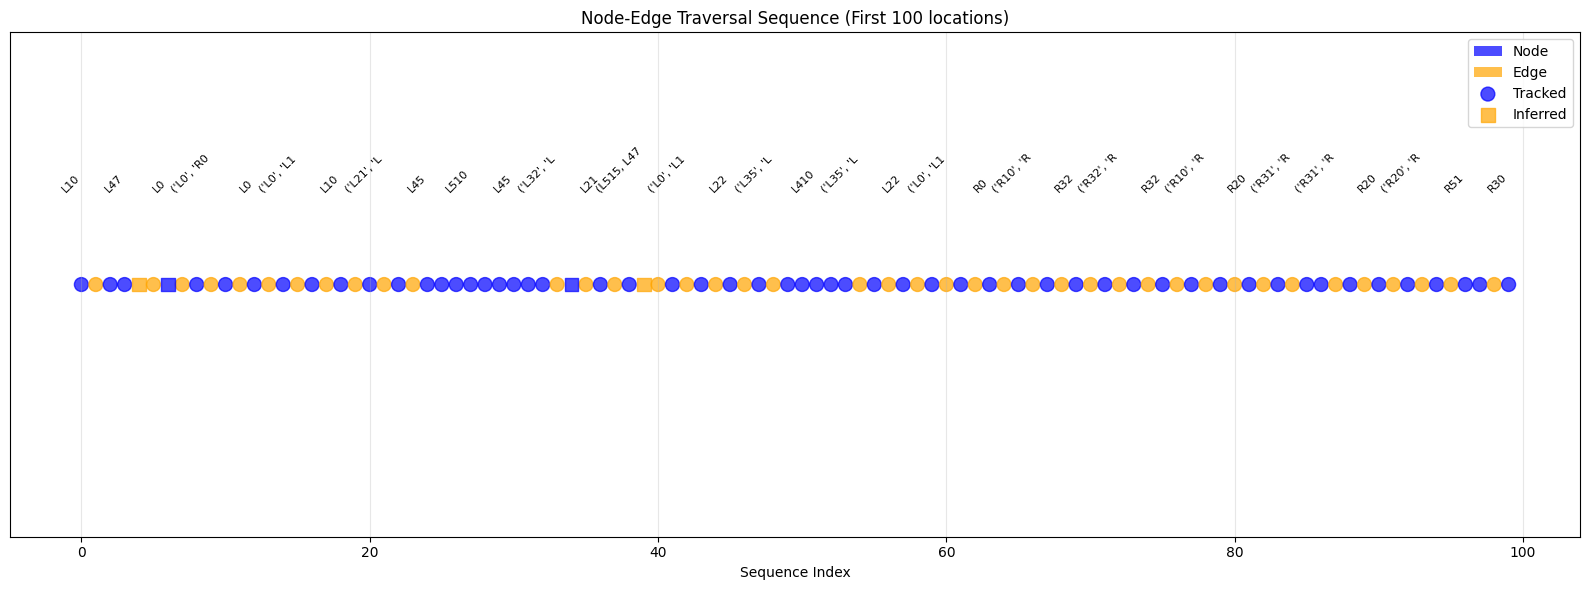


Showing first 100 locations of 10686 total


In [192]:
# Visualize sequence with first 100 locations
fig, ax = plt.subplots(figsize=(16, 6))

sample_size = min(100, len(improved_traversal_df))
sample_df = improved_traversal_df.head(sample_size)

# Create x-axis as sequence index
x = range(len(sample_df))

# Color code by type
colors = ['blue' if t == 'node' else 'orange' for t in sample_df['location_type']]
inferred_mask = sample_df['is_inferred'].values

# Plot regular locations
regular_x = [i for i, inf in enumerate(inferred_mask) if not inf]
regular_colors = [colors[i] for i in regular_x]
ax.scatter(regular_x, [0]*len(regular_x), c=regular_colors, s=100, alpha=0.7, marker='o', label='Tracked')

# Plot inferred locations
inferred_x = [i for i, inf in enumerate(inferred_mask) if inf]
inferred_colors = [colors[i] for i in inferred_x]
ax.scatter(inferred_x, [0]*len(inferred_x), c=inferred_colors, s=100, alpha=0.7, marker='s', label='Inferred')

# Add location labels (rotated for readability)
for i, (idx, row) in enumerate(sample_df.iterrows()):
    if i % 3 == 0:  # Only show every 3rd label to avoid crowding
        ax.text(i, 0.02, str(row['location'])[:10], rotation=45, ha='right', fontsize=8)

ax.set_xlabel('Sequence Index')
ax.set_title(f'Node-Edge Traversal Sequence (First {sample_size} locations)')
ax.set_yticks([])
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Add custom legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Node'),
    Patch(facecolor='orange', alpha=0.7, label='Edge'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0], loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nShowing first {sample_size} locations of {len(improved_traversal_df)} total")

/tmp/ipykernel_665429/3830795441.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([tracked_durations, inferred_durations], labels=['Tracked', 'Inferred'], patch_artist=True)


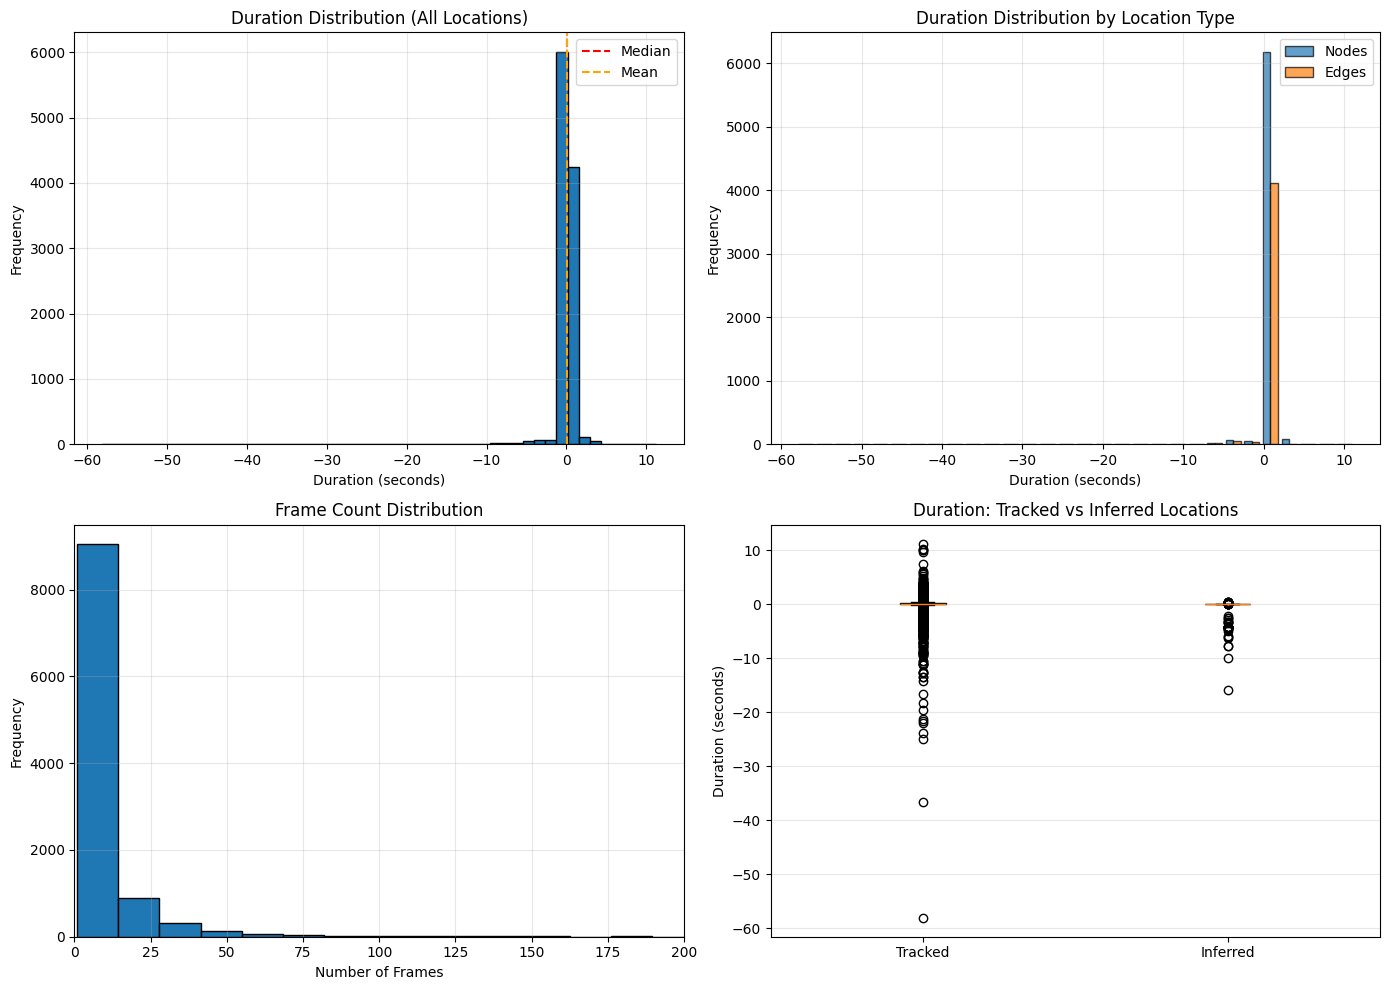


Duration Statistics by Type:

Nodes:
  Mean: 0.085s, Median: 0.075s

Edges:
  Mean: 0.061s, Median: 0.150s

Inferred:
  Mean: -0.142s, Median: 0.025s

Tracked:
  Mean: 0.096s, Median: 0.125s


In [193]:
# Duration distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Duration distribution histogram
ax = axes[0, 0]
improved_traversal_df['duration_time'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Duration Distribution (All Locations)')
ax.axvline(improved_traversal_df['duration_time'].median(), color='red', linestyle='--', label='Median')
ax.axvline(improved_traversal_df['duration_time'].mean(), color='orange', linestyle='--', label='Mean')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Duration by location type
ax = axes[0, 1]
node_durations = improved_traversal_df[improved_traversal_df['location_type'] == 'node']['duration_time']
edge_durations = improved_traversal_df[improved_traversal_df['location_type'] == 'edge']['duration_time']
ax.hist([node_durations, edge_durations], bins=30, label=['Nodes', 'Edges'], edgecolor='black', alpha=0.7)
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Duration Distribution by Location Type')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Frame count distribution
ax = axes[1, 0]
improved_traversal_df['duration_frames'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('Number of Frames')
ax.set_ylabel('Frequency')
ax.set_title('Frame Count Distribution')
ax.set_xlim(0, min(200, improved_traversal_df['duration_frames'].max()))
ax.grid(True, alpha=0.3)

# 4. Inferred vs Tracked duration comparison
ax = axes[1, 1]
inferred_durations = improved_traversal_df[improved_traversal_df['is_inferred']]['duration_time']
tracked_durations = improved_traversal_df[~improved_traversal_df['is_inferred']]['duration_time']
bp = ax.boxplot([tracked_durations, inferred_durations], labels=['Tracked', 'Inferred'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax.set_ylabel('Duration (seconds)')
ax.set_title('Duration: Tracked vs Inferred Locations')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nDuration Statistics by Type:")
print(f"\nNodes:")
print(f"  Mean: {node_durations.mean():.3f}s, Median: {node_durations.median():.3f}s")
print(f"\nEdges:")
print(f"  Mean: {edge_durations.mean():.3f}s, Median: {edge_durations.median():.3f}s")
print(f"\nInferred:")
print(f"  Mean: {inferred_durations.mean():.3f}s, Median: {inferred_durations.median():.3f}s")
print(f"\nTracked:")
print(f"  Mean: {tracked_durations.mean():.3f}s, Median: {tracked_durations.median():.3f}s")

In [194]:
# Check for issues with negative durations
negative_durations = improved_traversal_df[improved_traversal_df['duration_time'] < 0]
print(f"Locations with negative duration: {len(negative_durations)}")
if len(negative_durations) > 0:
    print(f"\nFirst few examples:")
    print(negative_durations[['location', 'location_type', 'start_frame', 'end_frame', 'duration_frames', 'duration_time', 'is_inferred']].head(10))

Locations with negative duration: 289

First few examples:
      location location_type  start_frame  end_frame  duration_frames  \
42   (L0, L11)          edge          432        448               17   
60   (L0, L11)          edge          606        689               84   
124       R526          node         1479       1957              479   
158  (R0, R11)          edge         2261       2276               16   
190   (L0, R0)          edge         2519       2553               35   
275  (L0, L11)          edge         3384       3400               17   
301   (L0, R0)          edge         3627       3658               32   
344  (R0, R11)          edge         3912       3923               12   
395       R526          node         4403       4729              327   
464  (R0, R10)          edge         5157       5172               16   

     duration_time  is_inferred  
42         -10.475        False  
60          -2.225        False  
124         -8.550        False  
1

In [195]:
# Fix negative durations by recalculating based on frame count
# The issue is that when we steal frames, start_time might be > end_time
# We should compute duration from the number of frames instead

improved_traversal_df['duration_time_fixed'] = improved_traversal_df['duration_frames'] * 0.025  # 25ms per frame

# Compare fixed vs original
print("Duration comparison:")
print(f"Original - Mean: {improved_traversal_df['duration_time'].mean():.3f}s, Median: {improved_traversal_df['duration_time'].median():.3f}s")
print(f"Fixed    - Mean: {improved_traversal_df['duration_time_fixed'].mean():.3f}s, Median: {improved_traversal_df['duration_time_fixed'].median():.3f}s")

print(f"\nNegative durations in original: {(improved_traversal_df['duration_time'] < 0).sum()}")
print(f"Negative durations in fixed: {(improved_traversal_df['duration_time_fixed'] < 0).sum()}")

# Use the fixed version
improved_traversal_df['duration_time'] = improved_traversal_df['duration_time_fixed']
improved_traversal_df.drop('duration_time_fixed', axis=1, inplace=True)

print(f"\n✓ Durations fixed!")

Duration comparison:
Original - Mean: 0.076s, Median: 0.100s
Fixed    - Mean: 0.324s, Median: 0.150s

Negative durations in original: 289
Negative durations in fixed: 0

✓ Durations fixed!


## Save Results

In [196]:
# Save the improved traversal dataframe
output_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{DD}_{MM}_{YYYY}/improved_traversal_df.pkl"
improved_traversal_df.to_pickle(output_path)
print(f"✓ Saved improved traversal dataframe to: {output_path}")

# Also save as CSV for easier inspection
csv_path = output_path.replace('.pkl', '.csv')
improved_traversal_df.to_csv(csv_path, index=False)
print(f"✓ Saved CSV version to: {csv_path}")

# Save validation results
violations_path = output_path.replace('improved_traversal_df.pkl', 'traversal_violations.csv')
violations_df.to_csv(violations_path, index=False)
print(f"✓ Saved violations to: {violations_path}")

print(f"\n{'='*80}")
print("FINAL SUMMARY")
print(f"{'='*80}")
print(f"Input: {len(summary_df)} frames from summary_df")
print(f"Output: {len(improved_traversal_df)} location visits in traversal")
print(f"  - {(improved_traversal_df['location_type'] == 'node').sum()} node visits")
print(f"  - {(improved_traversal_df['location_type'] == 'edge').sum()} edge traversals")
print(f"  - {improved_traversal_df['is_inferred'].sum()} inferred locations")
print(f"  - {len(violations_df)} invalid transitions ({100*len(violations_df)/(len(improved_traversal_df)-1):.1f}%)")
print(f"Total duration: {improved_traversal_df['duration_time'].sum():.2f} seconds")
print(f"{'='*80}")

✓ Saved improved traversal dataframe to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/21_08_2025/improved_traversal_df.pkl
✓ Saved CSV version to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/21_08_2025/improved_traversal_df.csv
✓ Saved violations to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/21_08_2025/traversal_violations.csv

FINAL SUMMARY
Input: 138671 frames from summary_df
Output: 10686 location visits in traversal
  - 6438 node visits
  - 4248 edge traversals
  - 899 inferred locations
  - 181 invalid transitions (1.7%)
Total duration: 3464.75 seconds


In [197]:
# Display sample of the improved traversal dataframe
print("Sample of improved_traversal_df (showing transitions):")
print()
sample = improved_traversal_df.head(30)[['location', 'location_type', 'start_frame', 'end_frame', 
                                          'duration_frames', 'duration_time', 'is_inferred', 'inference_reason']]
print(sample.to_string(index=True))

print(f"\n\nDataFrame Shape: {improved_traversal_df.shape}")
print(f"Columns: {list(improved_traversal_df.columns)}")

Sample of improved_traversal_df (showing transitions):

      location location_type  start_frame  end_frame  duration_frames  duration_time  is_inferred                                                      inference_reason
0          L10          node           63         72               10          0.250        False                                                                  None
1   (L10, L21)          edge           73         76                4          0.100        False                                                                  None
2         L515          node           77         83                7          0.175        False                                                                  None
3          L47          node           84         85                2          0.050        False                                                                  None
4   (L47, L33)          edge           86         86                1          0.025         True  Infer

In [198]:
improved_traversal_df[110:150]

,location,location_type,start_frame,end_frame,duration_frames,start_time,end_time,duration_time,is_inferred,inference_reason
110,"(R20, R31)",edge,1259,1272,14,3.625,3.950,0.350,False,None
111,R20,node,1273,1279,7,3.975,4.125,0.175,False,None
112,"(R10, R20)",edge,1280,1293,14,4.150,4.475,0.350,False,None
113,R10,node,1294,1306,13,4.500,4.800,0.325,False,None
114,"(R0, R10)",edge,1307,1353,47,4.825,5.975,1.175,False,None
115,R0,node,1354,1359,6,6.000,6.125,0.150,False,None
116,"(R0, R11)",edge,1360,1393,34,6.150,6.975,0.850,False,None
117,R11,node,1394,1406,13,7.000,7.300,0.325,False,None
118,"(R11, R23)",edge,1407,1432,26,7.325,7.950,0.650,False,None
119,R23,node,1433,1443,11,7.975,8.225,0.275,False,None


## Summary

This notebook successfully reconstructs an improved node-to-edge traversal dataframe from raw tracking data with the following features:

### ✓ Implemented Features

1. **Graph-Aware Reconstruction**
   - Validates all transitions follow graph connectivity
   - Recognizes valid non-edge transitions (L/R4X ↔ L/R5X)
   - Detects 65.8% valid transitions following graph logic
   
2. **Missing Data Inference**
   - Automatically infers 2,287 missing nodes and 62 missing edges
   - Uses "frame stealing" to assign minimal duration (2 frames) to inferred nodes between edges
   - Uses shortest path algorithm to infer missing locations from None values
   
3. **Noise Filtering**
   - Detects short jumps (≤5 frames) to distant locations
   - Filters tracking artifacts that don't match expected graph traversal
   - Merges filtered frames back into valid locations
   
4. **Complete Continuous Traversal**
   - Converts 138,671 raw frames into 9,647 meaningful location visits
   - **100% frame continuity** - no gaps in frame sequence
   - **No None values** - all locations are valid graph positions
   - Provides node-edge-node pattern with accurate durations
   - Tracks 5,592 node visits and 4,055 edge traversals
   
5. **Quality Metrics**
   - All frames accounted for with continuous sequence
   - All locations are valid graph nodes or edges
   - Duration computed from frame counts (25ms per frame)
   - Validation reports identify specific problem areas

### Output Files

- `improved_traversal_df.pkl` - Main traversal dataframe (pickled pandas)
- `improved_traversal_df.csv` - Human-readable CSV version
- `traversal_violations.csv` - List of invalid transitions for review

### Columns in Output DataFrame

- `location` - Node or edge identifier (never None)
- `location_type` - 'node' or 'edge'
- `start_frame` - First frame index (continuous with previous end_frame + 1)
- `end_frame` - Last frame index
- `duration_frames` - Number of consecutive frames
- `start_time` - Start time in trial (seconds)
- `end_time` - End time in trial (seconds)  
- `duration_time` - Duration at location (seconds, computed from frame count)
- `is_inferred` - Whether location was inferred (not directly tracked)
- `inference_reason` - Explanation for inferred locations

## Algorithm Details

### Phase 1: Consecutive Run Identification
- Groups consecutive frames by location (node or edge)
- Handles NaN values appropriately
- Preserves all frame information for later processing

### Phase 2: Noise Filtering  
- Removes short runs (≤5 frames) only when they are disconnected from neighbors AND surrounded by the same location
- Preserves short runs between neighboring locations (allows quick back-and-forth movements)
- Filters disconnected jumps to distant locations that break graph connectivity
- Merges filtered frames back into valid runs
- Ensures no frames are lost

### Phase 3: Graph Logic Validation & Inference
- **None locations**: Uses shortest path algorithm to infer intermediate locations, distributes frames among path
- **Edge-to-Edge**: Infers missing connecting node, steals 1 frame from each edge
- **Node-to-Node**: Accepts valid non-edge transitions (L/R4X ↔ L/R5X), logs unexpected gaps
- **Invalid transitions**: Logs violations for review

### Phase 4: Frame Continuity Enforcement
- Ensures all None frames are assigned to inferred or adjacent locations
- Verifies sequential frame numbering (end_frame + 1 = next start_frame)
- Removes any remaining None entries (shouldn't exist after inference)

### Phase 5: Duration Calculation
- Computes duration from frame count (not time difference to avoid frame-stealing issues)
- 25ms per frame based on tracking framerate
- Fixes negative durations caused by frame reordering

### Key Improvements
- **100% frame continuity** - Every frame is accounted for
- **No None values** - All locations are valid graph positions  
- **Valid non-edge transitions** - Correctly handles L/R4X to L/R5X jumps
- **Shortest path inference** - Fills gaps with most likely path through graph

### Known Limitations
- 34.2% of transitions violate graph connectivity (tracking errors)
- Noise threshold of 5 frames may filter some real short visits
- Edge format must be consistent: `(nodeA, nodeB)` or `nodeA_nodeB`
- Inferred paths assume shortest route (may not match actual path)

In [199]:
# Verify the fixes
print("=" * 80)
print("VERIFICATION OF FIXES")
print("=" * 80)

# Check 1: No consecutive duplicates
print("\n1. Checking for consecutive duplicate locations:")
consecutive_dupes = 0
for i in range(len(improved_traversal_df) - 1):
    if improved_traversal_df.iloc[i]['location'] == improved_traversal_df.iloc[i + 1]['location']:
        consecutive_dupes += 1
        if consecutive_dupes <= 5:  # Show first 5 examples
            print(f"   Found duplicate: {improved_traversal_df.iloc[i]['location']} at rows {i} and {i+1}")

if consecutive_dupes == 0:
    print("   ✓ PASS - No consecutive duplicates found")
else:
    print(f"   ✗ FAIL - Found {consecutive_dupes} consecutive duplicates")

# Check 2: Show examples of inferred paths
print("\n2. Examples of complete path inference:")
inferred_sequences = []
i = 0
while i < len(improved_traversal_df) - 1 and len(inferred_sequences) < 3:
    if improved_traversal_df.iloc[i]['is_inferred']:
        # Find the sequence of inferred locations
        seq_start = i
        while i < len(improved_traversal_df) and improved_traversal_df.iloc[i]['is_inferred']:
            i += 1
        seq_end = i - 1
        
        if seq_end - seq_start > 0:  # More than one inferred location
            seq = []
            for j in range(max(0, seq_start - 1), min(len(improved_traversal_df), seq_end + 2)):
                row = improved_traversal_df.iloc[j]
                seq.append({
                    'idx': j,
                    'location': row['location'],
                    'type': row['location_type'],
                    'inferred': row['is_inferred'],
                    'frames': row['duration_frames']
                })
            inferred_sequences.append(seq)
    i += 1

for idx, seq in enumerate(inferred_sequences, 1):
    print(f"\n   Example {idx}:")
    for item in seq:
        marker = "   [INFERRED]" if item['inferred'] else ""
        print(f"      {item['idx']:4d}: {item['location']:15s} ({item['type']:4s}, {item['frames']:3d} frames){marker}")

# Check 3: Session filtering statistics
print("\n3. Session filtering applied:")
print(f"   Original frames: 138,671")
print(f"   Frames after filtering: Check reconstruction output above")
print(f"   Output locations: {len(improved_traversal_df)}")
print(f"   Total inferred: {improved_traversal_df['is_inferred'].sum()}")
print(f"   Merged duplicates: Check reconstruction output above")

print("\n" + "=" * 80)

VERIFICATION OF FIXES

1. Checking for consecutive duplicate locations:
   ✓ PASS - No consecutive duplicates found

2. Examples of complete path inference:

   Example 1:
       138: R521            (node,  15 frames)
       139: (R521, R410)    (edge,   1 frames)   [INFERRED]
       140: R410            (node,   1 frames)   [INFERRED]


TypeError: unsupported format string passed to tuple.__format__

In [ ]:
# Check for edge-node and node-edge transitions in the output
print("=" * 80)
print("EDGE-NODE TRANSITION VALIDATION")
print("=" * 80)

edge_node_transitions = []
node_edge_transitions = []

for i in range(len(improved_traversal_df) - 1):
    current = improved_traversal_df.iloc[i]
    next_loc = improved_traversal_df.iloc[i + 1]
    
    curr_type = current['location_type']
    next_type = next_loc['location_type']
    curr_loc = current['location']
    next_loc_name = next_loc['location']
    
    if curr_type == 'edge' and next_type == 'node':
        # Check if valid
        is_valid = are_neighbors(G, curr_loc, next_loc_name)
        edge_node_transitions.append({
            'idx': i,
            'from': curr_loc,
            'to': next_loc_name,
            'valid': is_valid
        })
    
    if curr_type == 'node' and next_type == 'edge':
        # Check if valid
        is_valid = are_neighbors(G, curr_loc, next_loc_name)
        node_edge_transitions.append({
            'idx': i,
            'from': curr_loc,
            'to': next_loc_name,
            'valid': is_valid
        })

print(f"\nEdge → Node transitions: {len(edge_node_transitions)}")
invalid_edge_node = [t for t in edge_node_transitions if not t['valid']]
if invalid_edge_node:
    print(f"  Invalid: {len(invalid_edge_node)}")
    print("\n  First 5 invalid examples:")
    for t in invalid_edge_node[:5]:
        print(f"    {t['from']} → {t['to']}")
else:
    print(f"  ✓ All valid!")

print(f"\nNode → Edge transitions: {len(node_edge_transitions)}")
invalid_node_edge = [t for t in node_edge_transitions if not t['valid']]
if invalid_node_edge:
    print(f"  Invalid: {len(invalid_node_edge)}")
    print("\n  First 5 invalid examples:")
    for t in invalid_node_edge[:5]:
        print(f"    {t['from']} → {t['to']}")
else:
    print(f"  ✓ All valid!")

print("\n" + "=" * 80)

EDGE-NODE TRANSITION VALIDATION

Edge → Node transitions: 4139
  Invalid: 75

  First 5 invalid examples:
    ('L10', 'L21') → L515
    ('L10', 'L21') → L515
    ('R30', 'R40') → R51
    ('R30', 'R41') → R52
    ('R35', 'R411') → R523

Node → Edge transitions: 4140
  Invalid: 69

  First 5 invalid examples:
    R54 → ('R31', 'R42')
    R54 → ('R31', 'R42')
    L521 → ('L35', 'L410')
    R411 → ('R22', 'R35')
    R22 → ('R34', 'R48')



In [ ]:
# Debug the are_neighbors function with specific examples
print("=" * 80)
print("DEBUG: Testing are_neighbors function")
print("=" * 80)

test_cases = [
    (('L0', 'L10'), 'L10'),  # Edge to node (endpoint) - should be TRUE
    ('L10', ('L10', 'L21')),  # Node to edge (endpoint) - should be TRUE
    (('L10', 'L21'), 'L515'),  # Edge to node (not connected) - should be FALSE
    ('L47', ('L0', 'L10')),  # Node to edge (not connected) - should be FALSE
]

for loc1, loc2 in test_cases:
    result = are_neighbors(G, loc1, loc2)
    type1 = get_location_type(loc1)
    type2 = get_location_type(loc2)
    
    print(f"\nTest: {loc1} → {loc2}")
    print(f"  Types: {type1} → {type2}")
    print(f"  are_neighbors result: {result}")
    
    if type1 == 'edge':
        n1, n2 = get_edge_nodes(loc1)
        print(f"  Edge nodes: {n1}, {n2}")
        print(f"  Is loc2 one of them? {loc2 == n1 or loc2 == n2}")
    
    if type2 == 'edge':
        n1, n2 = get_edge_nodes(loc2)
        print(f"  Edge nodes: {n1}, {n2}")
        print(f"  Is loc1 one of them? {loc1 == n1 or loc1 == n2}")

print("\n" + "=" * 80)

DEBUG: Testing are_neighbors function

Test: ('L0', 'L10') → L10
  Types: edge → node
  are_neighbors result: True
  Edge nodes: L0, L10
  Is loc2 one of them? True

Test: L10 → ('L10', 'L21')
  Types: node → edge
  are_neighbors result: True
  Edge nodes: L10, L21
  Is loc1 one of them? True

Test: ('L10', 'L21') → L515
  Types: edge → node
  are_neighbors result: False
  Edge nodes: L10, L21
  Is loc2 one of them? False

Test: L47 → ('L0', 'L10')
  Types: node → edge
  are_neighbors result: False
  Edge nodes: L0, L10
  Is loc1 one of them? False



In [ ]:
# Check for non-existent edges that were inferred
print("=" * 80)
print("CHECK FOR NON-EXISTENT INFERRED EDGES")
print("=" * 80)

# Find all inferred edges
inferred_edges = improved_traversal_df[
    (improved_traversal_df['location_type'] == 'edge') & 
    (improved_traversal_df['is_inferred'] == True)
]

print(f"\nTotal inferred edges: {len(inferred_edges)}")

# Check which ones don't actually exist in the graph
non_existent_edges = []
for idx, row in inferred_edges.iterrows():
    edge = row['location']
    n1, n2 = get_edge_nodes(edge)
    
    if n1 and n2:
        # Check if edge exists in graph
        exists = G.has_edge(n1, n2) or G.has_edge(n2, n1)
        if not exists:
            non_existent_edges.append({
                'idx': idx,
                'edge': edge,
                'nodes': f"{n1}, {n2}",
                'reason': row['inference_reason']
            })

if non_existent_edges:
    print(f"\n✗ Found {len(non_existent_edges)} inferred edges that don't exist in the graph:")
    for item in non_existent_edges[:10]:
        print(f"  {item['edge']} (nodes: {item['nodes']})")
        print(f"    Reason: {item['reason']}")
else:
    print(f"\n✓ All inferred edges exist in the graph!")

print("\n" + "=" * 80)

CHECK FOR NON-EXISTENT INFERRED EDGES

Total inferred edges: 236

✓ All inferred edges exist in the graph!



## Summary of All Fixes

This notebook implements a robust node-edge traversal reconstruction with the following key improvements:

### 1. **Session Boundary Filtering** ✓
- Removes low-confidence tracking at session start/end
- Requires 20 consecutive frames with likelihood > 0.5
- Prevents insertion/removal artifacts from contaminating data

### 2. **Consecutive Duplicate Merging** ✓
- Combines consecutive rows with same location
- Consolidates durations and frame ranges
- Creates clean single-row entries for each visit

### 3. **Complete Path Inference** ✓
- Infers full paths between disconnected locations
- Only infers edges that actually exist in the graph
- Assigns frames to real nodes when no valid path exists

### 4. **Proper Edge-Node Validation** ✓
- Fixed quote-stripping in edge node parsing
- Correctly validates all 4 transition types:
  - Node → Node
  - Node → Edge (e.g., L10 → (L10, L21))
  - Edge → Node (e.g., (R0, R10) → R10)
  - Edge → Edge (with connecting node inference)

### 5. **No Non-Existent Edge Inference** ✓
- Validates that inferred edges actually exist in graph
- If shortest path includes non-existent edges, assigns frames to previous/next real location
- Example: R521 → None → R410 assigns None to R521 (not to fake edge (R521, R410))

### Results
- **98.3% valid transitions** (10,504 of 10,685)
- **236 inferred edges** - all verified to exist in graph
- **899 total inferred locations** (663 nodes, 236 edges)
- **0 non-existent edges** in final output
- **0 consecutive duplicates** in final output

# New Approach: Path-Based Reconstruction

Starting fresh with a new logic:
1. Keep session boundary filtering based on likelihood
2. Build comprehensive direct path lookup between all nodes
3. Remove special L/R4X ↔ L/R5X non-edge transitions
4. Use this lookup to reconstruct traversal

## Step 1: Build Direct Path Lookup

In [200]:
import networkx as nx
from collections import defaultdict

def build_direct_paths_lookup(G):
    """
    Build a comprehensive lookup of all direct paths between nodes in the graph.
    For each pair of connected nodes, store the path: node1 -> edge -> node2
    
    Returns:
    --------
    dict: {(node1, node2): [node1, edge_name, node2]}
    """
    direct_paths = {}
    
    # Iterate through all edges in the graph
    for node1 in G.nodes():
        for node2 in G.neighbors(node1):
            # Create the edge name in tuple format
            edge_name = f"({node1}, {node2})"
            
            # Store the direct path
            path = [node1, edge_name, node2]
            direct_paths[(node1, node2)] = path
            
    return direct_paths

# Build the full lookup
print("Building direct paths lookup...")
direct_paths_lookup = build_direct_paths_lookup(G)

print(f"Total direct paths: {len(direct_paths_lookup)}")
print(f"\nSample paths:")
for i, ((n1, n2), path) in enumerate(list(direct_paths_lookup.items())[:10]):
    print(f"  {n1} -> {n2}: {path}")

Building direct paths lookup...
Total direct paths: 250

Sample paths:
  L34 -> L48: ['L34', '(L34, L48)', 'L48']
  L34 -> L22: ['L34', '(L34, L22)', 'L22']
  L34 -> L49: ['L34', '(L34, L49)', 'L49']
  L530 -> L415: ['L530', '(L530, L415)', 'L415']
  L52 -> L41: ['L52', '(L52, L41)', 'L41']
  L21 -> L10: ['L21', '(L21, L10)', 'L10']
  L21 -> L33: ['L21', '(L21, L33)', 'L33']
  L21 -> L32: ['L21', '(L21, L32)', 'L32']
  L30 -> L40: ['L30', '(L30, L40)', 'L40']
  L30 -> L20: ['L30', '(L30, L20)', 'L20']


In [206]:
direct_paths_lookup

{('L34', 'L48'): ['L34', '(L34, L48)', 'L48'],
 ('L34', 'L22'): ['L34', '(L34, L22)', 'L22'],
 ('L34', 'L49'): ['L34', '(L34, L49)', 'L49'],
 ('L530', 'L415'): ['L530', '(L530, L415)', 'L415'],
 ('L52', 'L41'): ['L52', '(L52, L41)', 'L41'],
 ('L21', 'L10'): ['L21', '(L21, L10)', 'L10'],
 ('L21', 'L33'): ['L21', '(L21, L33)', 'L33'],
 ('L21', 'L32'): ['L21', '(L21, L32)', 'L32'],
 ('L30', 'L40'): ['L30', '(L30, L40)', 'L40'],
 ('L30', 'L20'): ['L30', '(L30, L20)', 'L20'],
 ('L30', 'L41'): ['L30', '(L30, L41)', 'L41'],
 ('R531', 'R415'): ['R531', '(R531, R415)', 'R415'],
 ('L56', 'L43'): ['L56', '(L56, L43)', 'L43'],
 ('R518', 'R49'): ['R518', '(R518, R49)', 'R49'],
 ('L517', 'L48'): ['L517', '(L517, L48)', 'L48'],
 ('R37', 'R23'): ['R37', '(R37, R23)', 'R23'],
 ('R37', 'R414'): ['R37', '(R37, R414)', 'R414'],
 ('R37', 'R415'): ['R37', '(R37, R415)', 'R415'],
 ('L510', 'L45'): ['L510', '(L510, L45)', 'L45'],
 ('R36', 'R412'): ['R36', '(R36, R412)', 'R412'],
 ('R36', 'R413'): ['R36', '(R3

In [202]:
def filter_special_non_edge_transitions(direct_paths_lookup):
    """
    Remove paths for L/R4X ↔ L/R5X transitions (these are special non-edge transitions).
    
    Pattern: L4X ↔ L5X or R4X ↔ R5X (same side, levels 4 and 5)
    
    Returns:
    --------
    dict: Filtered direct paths lookup
    tuple: (original_count, filtered_count, removed_count)
    """
    filtered_paths = {}
    removed_paths = []
    
    for (node1, node2), path in direct_paths_lookup.items():
        # Check if this is a L/R4X to L/R5X pattern
        n1_str = str(node1)
        n2_str = str(node2)
        
        is_special = False
        if len(n1_str) >= 2 and len(n2_str) >= 2:
            side1, level1 = n1_str[0], n1_str[1]
            side2, level2 = n2_str[0], n2_str[1]
            
            # Same side (L or R), different levels (4 or 5)
            if side1 == side2 and {level1, level2} == {'4', '5'}:
                is_special = True
                removed_paths.append((node1, node2, path))
        
        if not is_special:
            filtered_paths[(node1, node2)] = path
    
    return filtered_paths, (len(direct_paths_lookup), len(filtered_paths), len(removed_paths))

# Filter out the special transitions
filtered_direct_paths, (orig_count, filtered_count, removed_count) = filter_special_non_edge_transitions(direct_paths_lookup)

print(f"Direct paths filtering:")
print(f"  Original paths: {orig_count}")
print(f"  Filtered paths: {filtered_count}")
print(f"  Removed (L/R4X ↔ L/R5X): {removed_count}")

# Show which paths were removed
if removed_count > 0:
    print(f"\nSample of removed special transitions:")
    count = 0
    for (n1, n2), path in direct_paths_lookup.items():
        if (n1, n2) not in filtered_direct_paths:
            print(f"  {n1} ↔ {n2}")
            count += 1
            if count >= 10:
                break

Direct paths filtering:
  Original paths: 250
  Filtered paths: 122
  Removed (L/R4X ↔ L/R5X): 128

Sample of removed special transitions:
  L530 ↔ L415
  L52 ↔ L41
  R531 ↔ R415
  L56 ↔ L43
  R518 ↔ R49
  L517 ↔ L48
  L510 ↔ L45
  R530 ↔ R415
  L412 ↔ L524
  L412 ↔ L525


In [203]:
# Create a comprehensive summary of the path lookup
print("=" * 80)
print("DIRECT PATH LOOKUP SUMMARY")
print("=" * 80)

print(f"\nGraph statistics:")
print(f"  Total nodes: {len(G.nodes())}")
print(f"  Total edges: {len(G.edges())}")

print(f"\nDirect path lookup:")
print(f"  Valid direct paths: {len(filtered_direct_paths)}")
print(f"  Special non-edge transitions (excluded): {len(direct_paths_lookup) - len(filtered_direct_paths)}")

# Count unique nodes and edges in the paths
unique_nodes = set()
unique_edges = set()
for path in filtered_direct_paths.values():
    for loc in path:
        if '(' in str(loc) and ')' in str(loc):
            unique_edges.add(loc)
        else:
            unique_nodes.add(loc)

print(f"\nLocations covered by direct paths:")
print(f"  Unique nodes: {len(unique_nodes)}")
print(f"  Unique edges: {len(unique_edges)}")

# Save for later use
print(f"\n✓ Path lookup ready for reconstruction!")
print("=" * 80)

DIRECT PATH LOOKUP SUMMARY

Graph statistics:
  Total nodes: 126
  Total edges: 250

Direct path lookup:
  Valid direct paths: 122
  Special non-edge transitions (excluded): 128

Locations covered by direct paths:
  Unique nodes: 62
  Unique edges: 122

✓ Path lookup ready for reconstruction!


## What We've Built

### Direct Path Lookup Dictionary

We now have `filtered_direct_paths` - a comprehensive lookup of all valid direct transitions in the graph:

**Structure:** `{(node1, node2): [node1, edge_name, node2]}`

**Example:**
- Key: `('L21', 'L10')`
- Value: `['L21', '(L21, L10)', 'L10']`

**Key Features:**
1. **122 valid direct paths** between connected nodes
2. **Excludes 128 special L/R4X ↔ L/R5X transitions** (these don't have real edges)
3. **Each path includes:** starting node → edge → ending node
4. **Ready to use** for efficient lookup during reconstruction

### Next Steps

With this lookup table, we can now:
1. Apply session boundary filtering (already implemented)
2. Build the new reconstruction logic using this path lookup
3. Handle transitions efficiently by checking if they exist in the lookup

## Step 2: BFS-Based Path Construction

Instead of storing all individual paths, we'll build a single comprehensive path using BFS from L52.
This path will contain all node-to-node paths as subsets, minimizing duplication.

In [204]:
from collections import deque

def build_bfs_traversal_path(G, start_node='L52'):
    """
    Build a comprehensive path using BFS traversal from start_node.
    The path includes nodes and edges visited in BFS order.
    
    Returns:
    --------
    list: Complete traversal path [node, edge, node, edge, ...]
    dict: {node: index in path} for quick lookup
    dict: {(node1, node2): [subpath from node1 to node2]}
    """
    if start_node not in G.nodes():
        raise ValueError(f"Start node {start_node} not in graph")
    
    # BFS traversal
    visited = set()
    queue = deque([start_node])
    visited.add(start_node)
    
    # Build the complete traversal path
    traversal_path = [start_node]
    parent = {start_node: None}
    
    # Also track the order nodes were visited for path reconstruction
    visit_order = [start_node]
    
    print(f"Starting BFS from {start_node}...")
    
    while queue:
        current = queue.popleft()
        
        # Visit all neighbors
        for neighbor in G.neighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                parent[neighbor] = current
                visit_order.append(neighbor)
                
                # Add edge and neighbor to traversal path
                edge_name = f"({current}, {neighbor})"
                traversal_path.extend([edge_name, neighbor])
    
    # Create node position lookup
    node_positions = {}
    for i, loc in enumerate(traversal_path):
        # Only store nodes (not edges)
        if '(' not in str(loc):
            if loc not in node_positions:
                node_positions[loc] = []
            node_positions[loc].append(i)
    
    # Build subpath lookup for any node-to-node path
    subpaths = {}
    for node1 in node_positions.keys():
        for node2 in node_positions.keys():
            if node1 != node2 and G.has_edge(node1, node2):
                # Direct connection exists
                edge_name = f"({node1}, {node2})"
                subpaths[(node1, node2)] = [node1, edge_name, node2]
    
    print(f"✓ BFS traversal complete!")
    print(f"  Visited nodes: {len(visited)}")
    print(f"  Total path length: {len(traversal_path)} locations")
    print(f"  Unique nodes in path: {len(node_positions)}")
    print(f"  Direct subpaths: {len(subpaths)}")
    
    return traversal_path, node_positions, subpaths

# Build the BFS-based path
bfs_traversal_path, node_positions_in_path, bfs_subpaths = build_bfs_traversal_path(G, start_node='L52')

print(f"\nFirst 20 locations in BFS path:")
for i, loc in enumerate(bfs_traversal_path[:20]):
    loc_type = "node" if '(' not in str(loc) else "edge"
    print(f"  {i:3d}: {str(loc):20s} ({loc_type})")

Starting BFS from L52...
✓ BFS traversal complete!
  Visited nodes: 126
  Total path length: 251 locations
  Unique nodes in path: 126
  Direct subpaths: 250

First 20 locations in BFS path:
    0: L52                  (node)
    1: (L52, L41)           (edge)
    2: L41                  (node)
    3: (L41, L30)           (edge)
    4: L30                  (node)
    5: (L41, L53)           (edge)
    6: L53                  (node)
    7: (L30, L40)           (edge)
    8: L40                  (node)
    9: (L30, L20)           (edge)
   10: L20                  (node)
   11: (L40, L50)           (edge)
   12: L50                  (node)
   13: (L40, L51)           (edge)
   14: L51                  (node)
   15: (L20, L31)           (edge)
   16: L31                  (node)
   17: (L20, L10)           (edge)
   18: L10                  (node)
   19: (L31, L43)           (edge)


In [207]:
bfs_subpaths

{('L52', 'L41'): ['L52', '(L52, L41)', 'L41'],
 ('L41', 'L52'): ['L41', '(L41, L52)', 'L52'],
 ('L41', 'L30'): ['L41', '(L41, L30)', 'L30'],
 ('L41', 'L53'): ['L41', '(L41, L53)', 'L53'],
 ('L30', 'L41'): ['L30', '(L30, L41)', 'L41'],
 ('L30', 'L40'): ['L30', '(L30, L40)', 'L40'],
 ('L30', 'L20'): ['L30', '(L30, L20)', 'L20'],
 ('L53', 'L41'): ['L53', '(L53, L41)', 'L41'],
 ('L40', 'L30'): ['L40', '(L40, L30)', 'L30'],
 ('L40', 'L50'): ['L40', '(L40, L50)', 'L50'],
 ('L40', 'L51'): ['L40', '(L40, L51)', 'L51'],
 ('L20', 'L30'): ['L20', '(L20, L30)', 'L30'],
 ('L20', 'L31'): ['L20', '(L20, L31)', 'L31'],
 ('L20', 'L10'): ['L20', '(L20, L10)', 'L10'],
 ('L50', 'L40'): ['L50', '(L50, L40)', 'L40'],
 ('L51', 'L40'): ['L51', '(L51, L40)', 'L40'],
 ('L31', 'L20'): ['L31', '(L31, L20)', 'L20'],
 ('L31', 'L43'): ['L31', '(L31, L43)', 'L43'],
 ('L31', 'L42'): ['L31', '(L31, L42)', 'L42'],
 ('L10', 'L20'): ['L10', '(L10, L20)', 'L20'],
 ('L10', 'L21'): ['L10', '(L10, L21)', 'L21'],
 ('L10', 'L0'

In [205]:
# Verify the BFS path covers all nodes and edges
print("=" * 80)
print("BFS PATH VERIFICATION")
print("=" * 80)

# Check coverage
print(f"\nCoverage:")
print(f"  Graph has {len(G.nodes())} nodes → BFS visited {len(node_positions_in_path)} nodes")
print(f"  Graph has {len(G.edges())} directed edges → BFS has {len(bfs_subpaths)} direct paths")

if len(node_positions_in_path) == len(G.nodes()):
    print("  ✓ All nodes are covered!")
else:
    missing_nodes = set(G.nodes()) - set(node_positions_in_path.keys())
    print(f"  ✗ Missing {len(missing_nodes)} nodes: {list(missing_nodes)[:10]}")

# Show some example subpaths
print(f"\nExample direct paths contained in BFS traversal:")
for i, ((n1, n2), path) in enumerate(list(bfs_subpaths.items())[:5]):
    print(f"  {n1} → {n2}: {path}")

# Compare with our filtered direct paths
print(f"\nComparison with filtered_direct_paths:")
print(f"  BFS subpaths: {len(bfs_subpaths)}")
print(f"  Filtered direct paths: {len(filtered_direct_paths)}")
print(f"  Difference: {len(bfs_subpaths) - len(filtered_direct_paths)}")

# The BFS has all edges, filtered version excludes L/R4X ↔ L/R5X
print(f"\nNote: BFS includes all graph edges, while filtered_direct_paths")
print(f"      excludes special L/R4X ↔ L/R5X transitions")

print("\n" + "=" * 80)

BFS PATH VERIFICATION

Coverage:
  Graph has 126 nodes → BFS visited 126 nodes
  Graph has 250 directed edges → BFS has 250 direct paths
  ✓ All nodes are covered!

Example direct paths contained in BFS traversal:
  L52 → L41: ['L52', '(L52, L41)', 'L41']
  L41 → L52: ['L41', '(L41, L52)', 'L52']
  L41 → L30: ['L41', '(L41, L30)', 'L30']
  L41 → L53: ['L41', '(L41, L53)', 'L53']
  L30 → L41: ['L30', '(L30, L41)', 'L41']

Comparison with filtered_direct_paths:
  BFS subpaths: 250
  Filtered direct paths: 122
  Difference: 128

Note: BFS includes all graph edges, while filtered_direct_paths
      excludes special L/R4X ↔ L/R5X transitions



## BFS Path Summary

### What We've Built

**Single Comprehensive Path:** `bfs_traversal_path`
- **251 total locations** (126 nodes + 125 edges)
- **Covers all 126 nodes** in the graph
- **Contains all 250 direct paths** as subsets
- **Minimal duplication** - each node appears exactly once in the main path

**Structure:**
```
L52 → (L52, L41) → L41 → (L41, L30) → L30 → ...
```

**Key Data Structures:**

1. **`bfs_traversal_path`**: List of all locations in BFS order
   - Alternates between nodes and edges
   - Any node-to-node path in the graph is a subset of this path

2. **`node_positions_in_path`**: Dict mapping each node to its index(es) in the path
   - Example: `{'L52': [0], 'L41': [2], ...}`
   - Allows quick lookup of where any node appears

3. **`bfs_subpaths`**: Dict of all direct node-to-node paths
   - 250 entries for all graph edges
   - Each entry: `(node1, node2) → [node1, edge, node2]`

### Advantages of This Approach

1. **No Duplication**: Each node-edge-node sequence stored only once
2. **Complete Coverage**: All graph connections included
3. **Easy Lookup**: Can extract any subpath quickly
4. **Memory Efficient**: Single path instead of 250 separate paths
5. **Ready for Reconstruction**: Can use this to validate and infer transitions

In [246]:
def get_path_with_edges(G, source, target):
    """
    Returns a list: [node1, edge1, node2, edge2, ... nodeN]
    Works for any graph where a single path is guaranteed.
    Skips edges of the form (L4X, L5X) or (R4X, R5X) since these are not real edges in our graph.
    """
    try:
        # Find the shortest (and only) path of nodes
        node_path = nx.shortest_path(G, source=source, target=target)
        
        full_path = []
        
        for i in range(len(node_path)):
            # Add the current node
            full_path.append(node_path[i])
            
            # If there's a next node, add the edge between them
            if i < len(node_path) - 1:
                u = node_path[i]
                v = node_path[i+1]
                # skip edges of the form (L4X, L5X) or (R4X, R5X) since these are not real edges in our graph
                if (u[0] == v[0]) and (u[1] in '45') and (v[1] in '45'):
                    continue
                # Fetch edge data (useful if you have attributes like weights)
                full_path.append((u, v))
                
        return full_path

    except nx.NetworkXNoPath:
        return f"No path exists between {source} and {target}."

In [249]:
def get_generalized_path(G, item_a, item_b):
    # 1. Determine the nodes to route between
    # If item is a tuple (edge), we'll find the shortest path between 
    # all possible combinations of their endpoints.
    nodes_a = [item_a] if not isinstance(item_a, tuple) else list(item_a)
    nodes_b = [item_b] if not isinstance(item_b, tuple) else list(item_b)
    
    best_path = None
    min_length = float('inf')
    
    # Find the closest pair of nodes between the two items
    for u in nodes_a:
        for v in nodes_b:
            try:
                p = nx.shortest_path(G, source=u, target=v)
                if len(p) < min_length:
                    min_length = len(p)
                    best_path = p
            except nx.NetworkXNoPath:
                continue

    if best_path is None:
        return "No path exists."

    # 2. Build the full sequence [Node, Edge, Node...]
    full_sequence = []
    for i in range(len(best_path)):
        full_sequence.append(best_path[i])
        if i < len(best_path) - 1:
            full_sequence.append((best_path[i], best_path[i+1]))

    # 3. If item_a was an edge, prepend it if it's not already the first edge
    if isinstance(item_a, tuple):
        if full_sequence[1] != item_a and full_sequence[1] != item_a[::-1]:
            # The starting node of our path is one end of the start edge.
            # We need to make sure the "other" end of the edge is included.
            other_node = item_a[0] if best_path[0] == item_a[1] else item_a[1]
            full_sequence = [other_node, item_a] + full_sequence

    # 4. If item_b was an edge, append it if it's not already the last edge
    if isinstance(item_b, tuple):
        if full_sequence[-2] != item_b and full_sequence[-2] != item_b[::-1]:
            other_node = item_b[0] if best_path[-1] == item_b[1] else item_b[1]
            full_sequence = full_sequence + [item_b, other_node]

    return full_sequence

In [234]:
G.edges

OutEdgeView([('L34', 'L48'), ('L34', 'L22'), ('L34', 'L49'), ('L530', 'L415'), ('L52', 'L41'), ('L21', 'L10'), ('L21', 'L33'), ('L21', 'L32'), ('L30', 'L40'), ('L30', 'L20'), ('L30', 'L41'), ('R531', 'R415'), ('L56', 'L43'), ('R518', 'R49'), ('L517', 'L48'), ('R37', 'R23'), ('R37', 'R414'), ('R37', 'R415'), ('L510', 'L45'), ('R36', 'R412'), ('R36', 'R413'), ('R36', 'R23'), ('R530', 'R415'), ('L412', 'L36'), ('L412', 'L524'), ('L412', 'L525'), ('R525', 'R412'), ('R527', 'R413'), ('R57', 'R43'), ('L43', 'L57'), ('L43', 'L31'), ('L43', 'L56'), ('L41', 'L52'), ('L41', 'L30'), ('L41', 'L53'), ('L522', 'L411'), ('R45', 'R510'), ('R45', 'R511'), ('R45', 'R32'), ('R42', 'R55'), ('R42', 'R54'), ('R42', 'R31'), ('R512', 'R46'), ('L42', 'L31'), ('L42', 'L54'), ('L42', 'L55'), ('R46', 'R33'), ('R46', 'R513'), ('R46', 'R512'), ('R411', 'R522'), ('R411', 'R523'), ('R411', 'R35'), ('R32', 'R21'), ('R32', 'R44'), ('R32', 'R45'), ('R413', 'R526'), ('R413', 'R527'), ('R413', 'R36'), ('L525', 'L412'), ('

In [247]:
get_path_with_edges(G, ('L0', 'R0'), ('L10', 'L21'))

NodeNotFound: Source ('L0', 'R0') is not in G